# Boosting Intuition and Methods
### Hands-on Notebook

**Learning Objectives**
1. Develop the intuition behind **Gradient Boosting**
2. Explore **sequential model improvement**

---
We'll predict used car resale price from mileage. Instead of training one model, we'll build the prediction up round by round, each round targeting whatever the ensemble still gets wrong.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(4)


## 1. Boosting by hand — 6 cars, two rounds

The exact worked example from the slides.


In [2]:
mileage = np.array([20, 45, 60, 80, 100, 130])
actual_price = np.array([18.0, 14.5, 12.0, 9.5, 8.0, 5.5])
X = mileage.reshape(-1, 1)
y = actual_price
learning_rate = 0.5

# Round 0: start with the simplest possible prediction — the mean
pred = np.full_like(y, y.mean(), dtype=float)
history = [{"round": 0, "prediction": pred.copy(), "mse": mean_squared_error(y, pred)}]
print(f"Round 0 (mean): pred={pred.round(2)}  MSE={history[0]['mse']:.2f}")


Round 0 (mean): pred=[11.25 11.25 11.25 11.25 11.25 11.25]  MSE=17.23


In [3]:
for round_num in [1, 2]:
    residual = y - pred                                  # what the ensemble still gets wrong
    stump = DecisionTreeRegressor(max_depth=1).fit(X, residual)   # fit a tiny model to the residual
    pred = pred + learning_rate * stump.predict(X)        # add a scaled correction
    mse = mean_squared_error(y, pred)
    history.append({"round": round_num, "prediction": pred.copy(), "mse": mse})
    print(f"Round {round_num}: pred={pred.round(2)}  MSE={mse:.2f}")


Round 1: pred=[13.04 13.04 13.04  9.46  9.46  9.46]  MSE=7.60
Round 2: pred=[14.65 14.65 12.24  8.66  8.66  8.66]  MSE=3.74


**Checkpoint:** this should match the slide — MSE 17.23 → 7.60 → 3.74 across the three rounds.


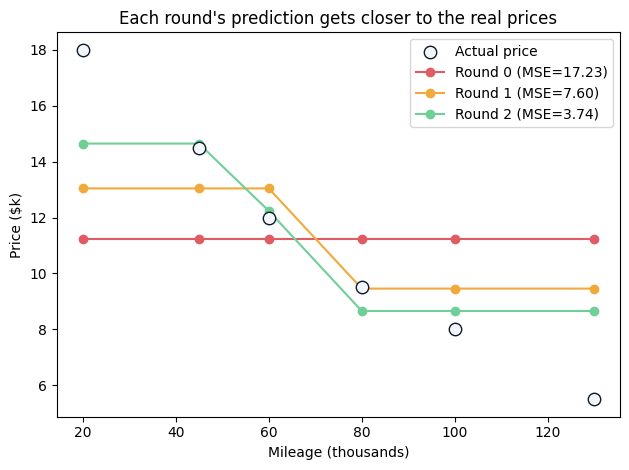

In [4]:
fig, ax = plt.subplots()
ax.scatter(mileage, actual_price, color="#F3F7FB", edgecolor="#0D1A2B", s=80, zorder=4, label="Actual price")
colors = ["#E15B64", "#F2A93B", "#6FCF97"]
for h, color in zip(history, colors):
    ax.plot(mileage, h["prediction"], marker="o", color=color, label=f"Round {h['round']} (MSE={h['mse']:.2f})")
ax.set_xlabel("Mileage (thousands)"); ax.set_ylabel("Price ($k)")
ax.set_title("Each round's prediction gets closer to the real prices")
ax.legend()
plt.tight_layout(); plt.show()


## 2. Why the learning rate matters

Same 150-car dataset, same 100 boosting rounds — only the learning rate changes.


In [5]:
np.random.seed(4)  # re-seed explicitly: Section 1's tree fits consumed some of the global random state
n = 150
mileage_l = np.random.uniform(5, 150, n)
age = np.random.uniform(0, 12, n)
condition_score = np.random.uniform(1, 10, n)
noise_col = np.random.uniform(0, 100, n)

true_price = 22 - 0.09*mileage_l - 0.6*age + 0.9*condition_score
price = np.clip(true_price + np.random.normal(0, 1.5, n), 2, None)

X_l = np.column_stack([mileage_l, age, condition_score, noise_col])
y_l = price
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_l, y_l, test_size=0.3, random_state=42)


In [6]:
rate_results = []
for rate in [0.01, 0.1, 1.0]:
    gb = GradientBoostingRegressor(n_estimators=100, learning_rate=rate, max_depth=2, random_state=42)
    gb.fit(Xl_train, yl_train)
    r2 = r2_score(yl_test, gb.predict(Xl_test))
    rate_results.append({"learning_rate": rate, "test_r2": r2})

pd.DataFrame(rate_results)


,learning_rate,test_r2
0,0.01,0.417869
1,0.10,0.801649
2,1.00,0.564700


**Checkpoint:** this should match the slide — R² of roughly 0.42 (rate=0.01, too slow), 0.80 (rate=0.1, balanced), and 0.57 (rate=1.0, too aggressive).


## 3. Boosting vs. a single model, at scale


In [7]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42).fit(Xl_train, yl_train)
gb_final = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42).fit(Xl_train, yl_train)

for name, model in [("Single tree", tree), ("Gradient Boosting", gb_final)]:
    pred = model.predict(Xl_test)
    print(f"{name}: RMSE={np.sqrt(mean_squared_error(yl_test, pred)):.2f}  R2={r2_score(yl_test, pred):.3f}")


Single tree: RMSE=3.55  R2=0.401
Gradient Boosting: RMSE=2.04  R2=0.802


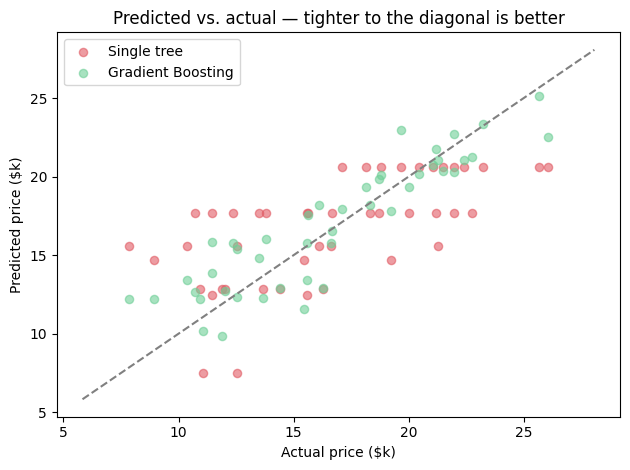

In [8]:
fig, ax = plt.subplots()
lims = [yl_test.min() - 2, yl_test.max() + 2]
ax.plot(lims, lims, "--", color="gray")
ax.scatter(yl_test, tree.predict(Xl_test), alpha=0.6, color="#E15B64", label="Single tree", s=35)
ax.scatter(yl_test, gb_final.predict(Xl_test), alpha=0.6, color="#6FCF97", label="Gradient Boosting", s=35)
ax.set_xlabel("Actual price ($k)"); ax.set_ylabel("Predicted price ($k)")
ax.set_title("Predicted vs. actual — tighter to the diagonal is better")
ax.legend()
plt.tight_layout(); plt.show()


**Checkpoint:** this should match the slide — single tree RMSE≈$3.55k/R²≈0.401, Gradient Boosting RMSE≈$2.04k/R²≈0.802.


## 4. Exercises


**Exercise 1.** Re-run the hand-worked example (Section 1) for a third round. Does MSE keep falling?


In [9]:
# TODO



<details><summary>Solution</summary>

```python
residual = y - pred
stump = DecisionTreeRegressor(max_depth=1).fit(X, residual)
pred = pred + learning_rate * stump.predict(X)
print(mean_squared_error(y, pred))
```
MSE typically keeps falling, though usually by a shrinking amount each round — there's less residual error left to correct, so each new stump has a smaller mistake to fix.
</details>


**Exercise 2.** Using `rate_results` from Section 2, find which learning rate gave the best test R² without hardcoding the value.


In [10]:
# TODO



<details><summary>Solution</summary>

```python
best = max(rate_results, key=lambda r: r["test_r2"])
print(best)
```
</details>


**Exercise 3.** Fit a `GradientBoostingRegressor` with `learning_rate=0.1` but only `n_estimators=10` instead of 100. How does its test R² compare to the 100-round version from Section 3?


In [11]:
# TODO



<details><summary>Solution</summary>

```python
gb_short = GradientBoostingRegressor(n_estimators=10, learning_rate=0.1, max_depth=2, random_state=42).fit(Xl_train, yl_train)
print(r2_score(yl_test, gb_short.predict(Xl_test)))
```
With only 10 rounds at a moderate learning rate, the ensemble hasn't had enough corrections yet — R² is typically noticeably lower than the 100-round result, the same "too slow" problem as the rate=0.01 case in Section 2, just reached by a different lever (fewer rounds instead of a smaller rate).
</details>


## 5. Recap

- **Gradient Boosting** builds an ensemble one model at a time: start simple, fit a new small model to the current residual error, add a scaled version of its correction, and repeat.
- **Sequential improvement** is visible directly in the MSE dropping round by round on the same 6 cars — each stump specifically targets what the ensemble still got wrong.
- The **learning rate** trades off speed against stability: too small wastes rounds, too large overshoots — a moderate rate with enough rounds outperforms both.
